### PAPER's Figure 1

In [7]:
#############################################
#BASIC PACKAGES
import sys
from copy import deepcopy as dcopy
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

#############################################
#PATH TO SCRIPTS FOLDER
path = '/data/AMARINS/CMBWLxHI-CODES/scripts/'
sys.path.insert(1, path)
import cross_functions_theory      as cxft
import handling_data               as hdata

#############################################
## MATPLOTLIB FEATURES
from matplotlib import cm
font = {'weight' : 'bold','size'   : 22}
mpl.rc('font', **font)
mpl.rc('font',   size=209)  #set defaults so that the plots are readable
mpl.rc('axes',   titlesize=20)
mpl.rc('axes',   labelsize=20)
mpl.rc('xtick',  labelsize=20)
mpl.rc('ytick',  labelsize=20)
mpl.rc('legend', fontsize =20)
mpl.rc('figure', titlesize=20)
mpl.rc('text',   usetex=True)
## FURTHER MATPLOTLIB FEATURES
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

## LOW-Z

In [4]:
##########################################
## THEORETICAL
## LSST Y10
prefix = ['LSST_bin0','LSST_bin9']
suffix = 'nch30_960_1260'
f1name = 'HI'
f2name = 'SHEAR'
bshear_names = np.array([     iprefix.split('_')[1] for iprefix in prefix    ])
bshear_used  = np.array([ int(ibin.split('bin')[1]) for ibin    in bshear_names ])
##########################################
## PATH to THEORECTICAL APS 
filepath_f1_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[0], suffix, f1=f1name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[1], suffix, f1=f1name)]
filepath_f2_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[0], suffix, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[1], suffix, f2=f2name)]
filepath_cx_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[0], suffix,f1=f1name, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[1], suffix,f1=f1name, f2=f2name)]
##
savefigs = True

In [5]:
##########################################
## LOADING DATA
Clf1_dict,Clf2_dict,Clcx_dict = {}, {}, {}
for i, (ibin, if1_path, if2_path, icx_path) in enumerate(zip(bshear_names, filepath_f1_LSSTY10, filepath_f2_LSSTY10, filepath_cx_LSSTY10)):
    ##
    clf1 = np.loadtxt(if1_path).T
    clf2 = np.loadtxt(if2_path).T
    clcx = np.loadtxt(icx_path ).T
    ##
    Clf1_dict[ibin] = cxft.cls_from_matrix2dict(clf1)
    Clf2_dict[ibin] = cxft.cls_from_matrix2dict(clf2)
    Clcx_dict[ibin] = cxft.cls_from_matrix2dict(clcx)
    ##
    nch = int(clf1.shape[0])-1
    del clf1, clf2, clcx

In [134]:
################################
# REDSHIFT TO BE REPRESENTED
N         = 4
zeff      = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['zeff']
ibins     = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['bins']
cticks    = dcopy(ibins)+1
bin_names = np.asarray( list(Clcx_dict[bshear_names[0]].keys())[1:])
################################

"/data/AMARINS/CMBWLxHI-CODES/images/['LSST_bin0', 'LSST_bin9']_cl_hi_theory__nch30_960_1260.png"

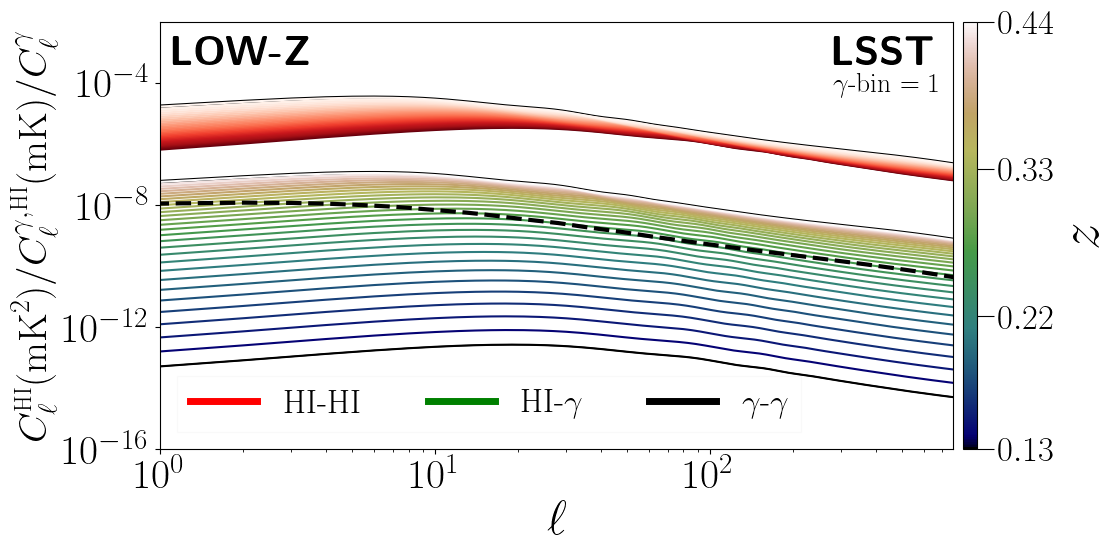

In [135]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.gist_earth)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
ishear = bshear_names[0]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK}^2)$' + r'$/$'+ r'$C^{\tiny{\gamma},\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK})$'+ r'$/$'+ r'$C^{\tiny{\gamma}}_{\ell}$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([1e-16, 1e-2])
ax.tick_params(axis='both', which='major', labelsize=30)
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='green',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='solid')]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{HI-}\gamma$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\gamma\textrm{-}\gamma$'#\ [\textrm{mK}^0]$'#\ (\textrm{m}=2)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1, y=4.0e-4, s=r'$\textbf{LOW-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-20, y=4.0e-4, s=r'$\textbf{LSST}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-20, y=0.5e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}.png".format( prefix, 'cl_hi_theory')
else:            pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}__{}.png".format(prefix, 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

"/data/AMARINS/CMBWLxHI-CODES/images/['LSST_bin0', 'LSST_bin9']_cl_hi_theory__nch30_960_1260.png"

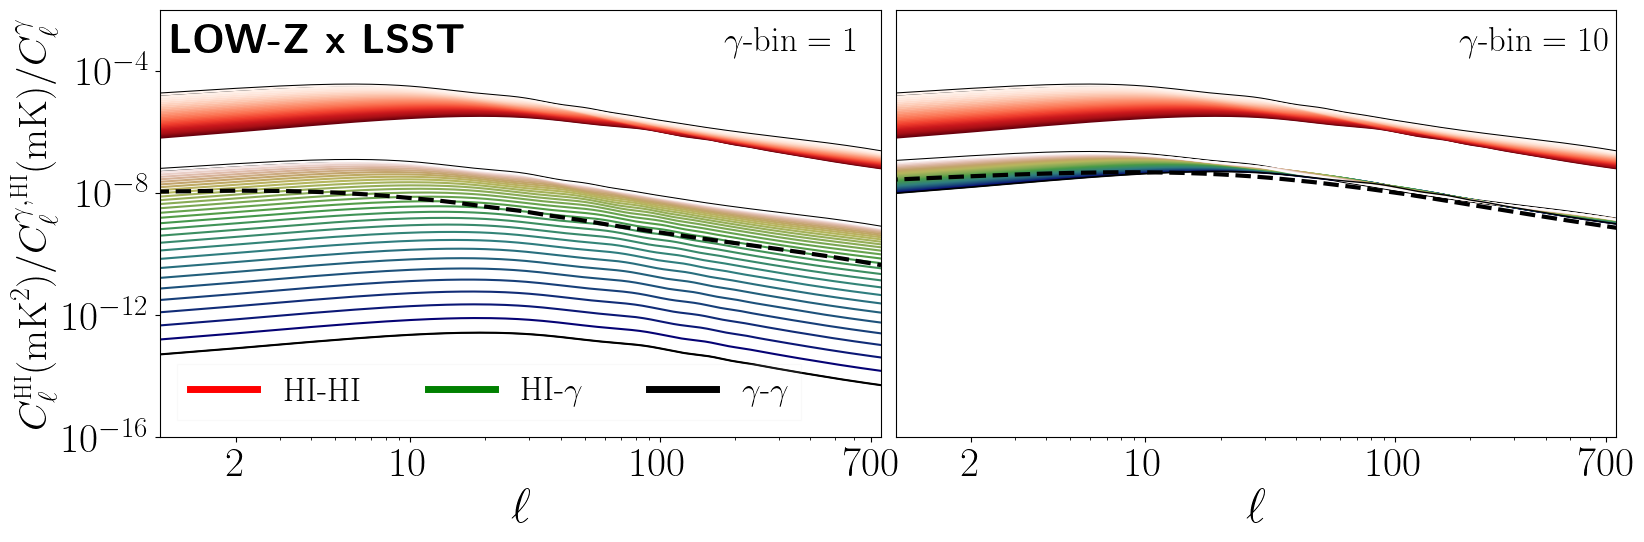

In [136]:
fig, axes  = plt.subplots(nrows=1, ncols=2)
plt.subplots_adjust(top=1.,right=2.4, wspace=0.02, )
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.gist_earth)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
ax = axes[0]
ishear = bshear_names[0]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK}^2)$' + r'$/$'+ r'$C^{\tiny{\gamma},\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK})$'+ r'$/$'+ r'$C^{\tiny{\gamma}}_{\ell}$', fontsize=29); 
ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-16, 1e-2])
ax.tick_params(axis='both', which='major', labelsize=30)
#
ax = axes[1]
ishear = bshear_names[1]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
ax.set_xlabel(r'$\ell$', fontsize=35)
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-16, 1e-2])
ax.set_yticks([])
ax.tick_params(axis='both', which='major', labelsize=30)
############################################################

###########################################################
ax = axes[0]
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='green',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='solid')]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{HI-}\gamma$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\gamma\textrm{-}\gamma$'#\ [\textrm{mK}^0]$'#\ (\textrm{m}=2)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1, y=4.0e-4, s=r'$\textbf{LOW-Z x LSST}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
axes[0].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[0].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
axes[1].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[1].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
###########################################################
if suffix==None: pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}.png".format( prefix, 'cl_hi_theory')
else:            pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}__{}.png".format(prefix, 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

In [8]:
### EUCLID
##########################################
## THEORETICAL
## LSST Y10
prefix = ['EUCLID_bin0','EUCLID_bin9']
suffix = 'nch30_980_1260'
f1name = 'HI'
f2name = 'SHEAR'
bshear_names = np.array([     iprefix.split('_')[1] for iprefix in prefix    ])
bshear_used  = np.array([ int(ibin.split('bin')[1]) for ibin    in bshear_names ])
##########################################
## PATH to THEORECTICAL APS 
filepath_f1_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[0], suffix, f1=f1name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[1], suffix, f1=f1name)]
filepath_f2_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[0], suffix, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[1], suffix, f2=f2name)]
filepath_cx_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[0], suffix,f1=f1name, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[1], suffix,f1=f1name, f2=f2name)]
##
savefigs = True

In [9]:
##########################################
## LOADING DATA
Clf1_dict,Clf2_dict,Clcx_dict = {}, {}, {}
for i, (ibin, if1_path, if2_path, icx_path) in enumerate(zip(bshear_names, filepath_f1_LSSTY10, filepath_f2_LSSTY10, filepath_cx_LSSTY10)):
    ##
    clf1 = np.loadtxt(if1_path).T
    clf2 = np.loadtxt(if2_path).T
    clcx = np.loadtxt(icx_path ).T
    ##
    Clf1_dict[ibin] = cxft.cls_from_matrix2dict(clf1)
    Clf2_dict[ibin] = cxft.cls_from_matrix2dict(clf2)
    Clcx_dict[ibin] = cxft.cls_from_matrix2dict(clcx)
    ##
    nch = int(clf1.shape[0])-1
    del clf1, clf2, clcx

In [10]:
################################
# REDSHIFT TO BE REPRESENTED
N         = 4
zeff      = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['zeff']
ibins     = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['bins']
cticks    = dcopy(ibins)+1
bin_names = np.asarray( list(Clcx_dict[bshear_names[0]].keys())[1:])
################################

"/data/AMARINS/CMBWLxHI-CODES/images/['EUCLID_bin0', 'EUCLID_bin9']_cl_hi_theory__nch30_980_1260.png"

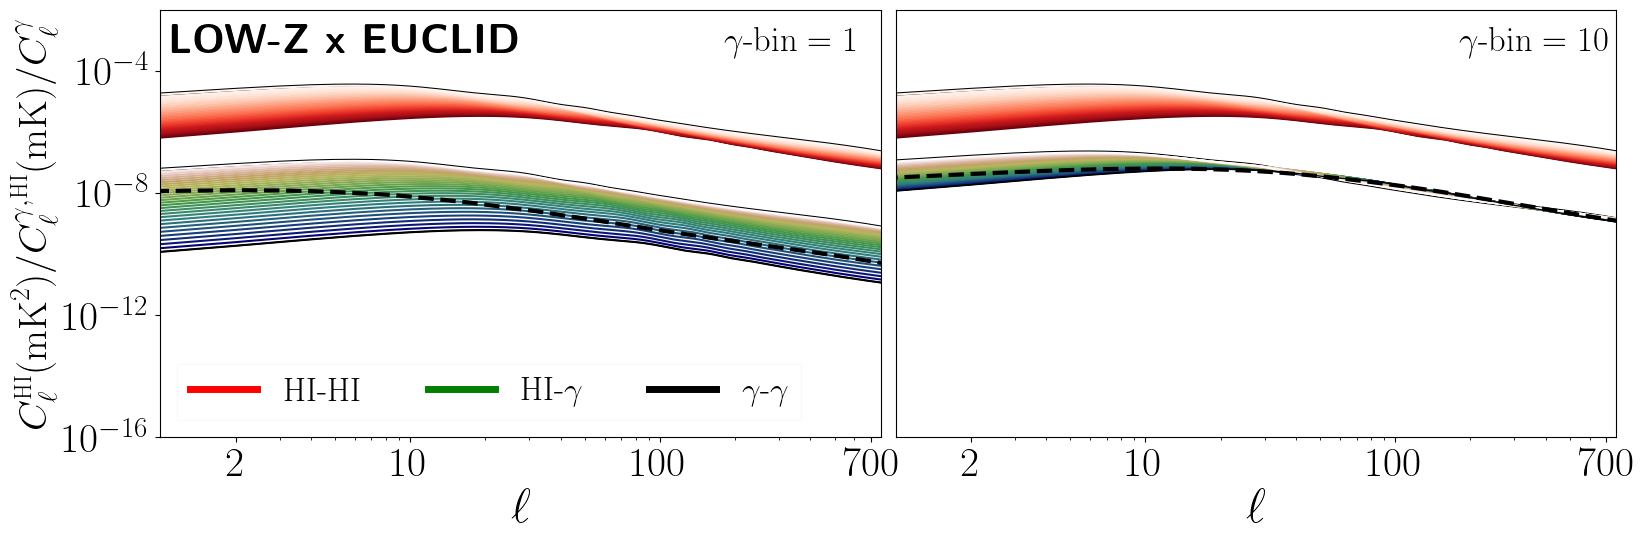

In [11]:
fig, axes  = plt.subplots(nrows=1, ncols=2)
plt.subplots_adjust(top=1.,right=2.4, wspace=0.02, )
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.gist_earth)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
ax = axes[0]
ishear = bshear_names[0]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK}^2)$' + r'$/$'+ r'$C^{\tiny{\gamma},\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK})$'+ r'$/$'+ r'$C^{\tiny{\gamma}}_{\ell}$', fontsize=29); 
ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-16, 1e-2])
ax.tick_params(axis='both', which='major', labelsize=30)
#
ax = axes[1]
ishear = bshear_names[1]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
ax.set_xlabel(r'$\ell$', fontsize=35)
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-16, 1e-2])
ax.set_yticks([])
ax.tick_params(axis='both', which='major', labelsize=30)
############################################################

###########################################################
ax = axes[0]
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='green',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='solid')]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{HI-}\gamma$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\gamma\textrm{-}\gamma$'#\ [\textrm{mK}^0]$'#\ (\textrm{m}=2)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1, y=4.0e-4, s=r'$\textbf{LOW-Z x EUCLID}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
axes[0].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[0].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
axes[1].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[1].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
###########################################################
if suffix==None: pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}.png".format( prefix, 'cl_hi_theory')
else:            pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}__{}.png".format(prefix, 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

## HIGH-Z

In [147]:
##########################################
## THEORETICAL
## LSST Y10
prefix = ['LSST_bin0','LSST_bin9']
suffix = 'nch70_350_1050'
f1name = 'HI'
f2name = 'SHEAR'
bshear_names = np.array([     iprefix.split('_')[1] for iprefix in prefix    ])
bshear_used  = np.array([ int(ibin.split('bin')[1]) for ibin    in bshear_names ])
##########################################
## PATH to THEORECTICAL APS 
filepath_f1_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[0], suffix, f1=f1name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[1], suffix, f1=f1name)]
filepath_f2_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[0], suffix, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[1], suffix, f2=f2name)]
filepath_cx_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[0], suffix,f1=f1name, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[1], suffix,f1=f1name, f2=f2name)]
##
savefigs = True

In [148]:
##########################################
## LOADING DATA
Clf1_dict,Clf2_dict,Clcx_dict = {}, {}, {}
for i, (ibin, if1_path, if2_path, icx_path) in enumerate(zip(bshear_names, filepath_f1_LSSTY10, filepath_f2_LSSTY10, filepath_cx_LSSTY10)):
    ##
    clf1 = np.loadtxt(if1_path).T
    clf2 = np.loadtxt(if2_path).T
    clcx = np.loadtxt(icx_path ).T
    ##
    Clf1_dict[ibin] = cxft.cls_from_matrix2dict(clf1)
    Clf2_dict[ibin] = cxft.cls_from_matrix2dict(clf2)
    Clcx_dict[ibin] = cxft.cls_from_matrix2dict(clcx)
    ##
    nch = int(clf1.shape[0])-1
    del clf1, clf2, clcx

In [149]:
################################
# REDSHIFT TO BE REPRESENTED
N         = 4
zeff      = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['zeff']
ibins     = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['bins']
cticks    = dcopy(ibins)+1
bin_names = np.asarray( list(Clcx_dict[bshear_names[0]].keys())[1:])
################################

"/data/AMARINS/CMBWLxHI-CODES/images/['LSST_bin0', 'LSST_bin9']_cl_hi_theory__nch70_350_1050.png"

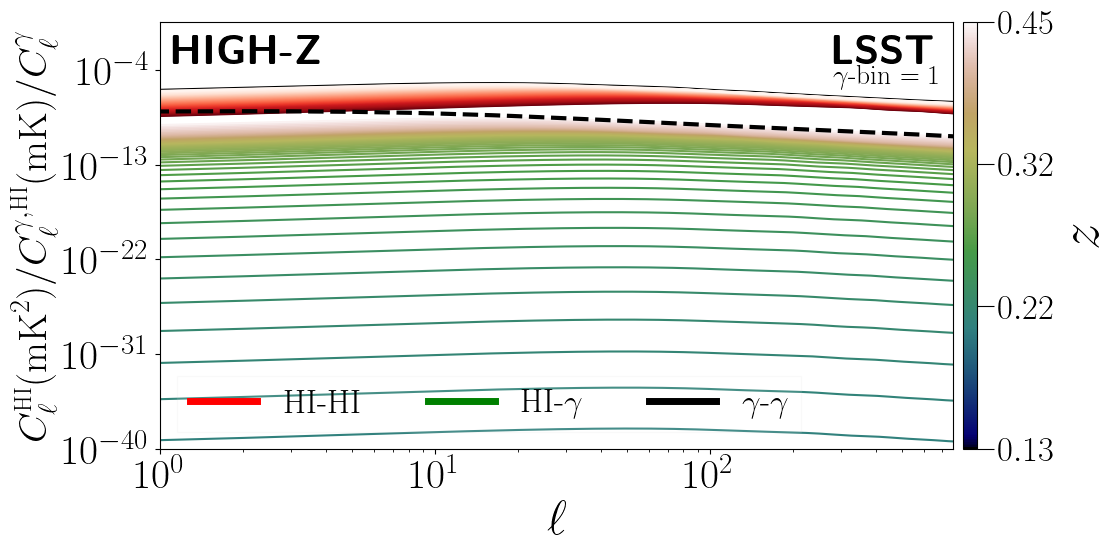

In [150]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.gist_earth)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
ishear = bshear_names[0]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK}^2)$' + r'$/$'+ r'$C^{\tiny{\gamma},\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK})$'+ r'$/$'+ r'$C^{\tiny{\gamma}}_{\ell}$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([1e-40, 4e0])
ax.tick_params(axis='both', which='major', labelsize=30)
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='green',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='solid')]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{HI-}\gamma$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\gamma\textrm{-}\gamma$'#\ [\textrm{mK}^0]$'#\ (\textrm{m}=2)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1, y=4.0e-4, s=r'$\textbf{HIGH-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-20, y=4.0e-4, s=r'$\textbf{LSST}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-20, y=0.05e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}.png".format( prefix, 'cl_hi_theory')
else:            pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}__{}.png".format(prefix, 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

"/data/AMARINS/CMBWLxHI-CODES/images/['LSST_bin0', 'LSST_bin9']_cl_hi_theory__nch70_350_1050.png"

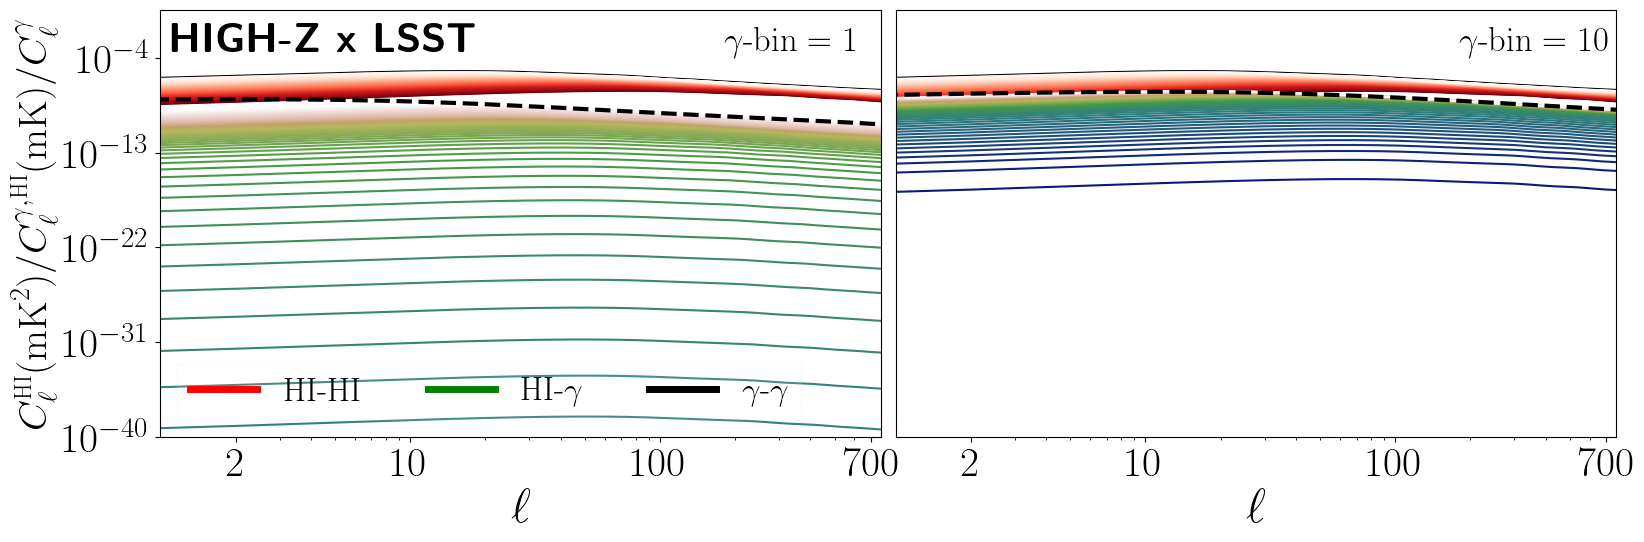

In [151]:
fig, axes  = plt.subplots(nrows=1, ncols=2)
plt.subplots_adjust(top=1.,right=2.4, wspace=0.02, )
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.gist_earth)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
ax = axes[0]
ishear = bshear_names[0]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK}^2)$' + r'$/$'+ r'$C^{\tiny{\gamma},\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK})$'+ r'$/$'+ r'$C^{\tiny{\gamma}}_{\ell}$', fontsize=29); 
ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-40, 4e0])
ax.tick_params(axis='both', which='major', labelsize=30)
#
ax = axes[1]
ishear = bshear_names[1]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
ax.set_xlabel(r'$\ell$', fontsize=35)
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-40, 4e0])
ax.set_yticks([])
ax.tick_params(axis='both', which='major', labelsize=30)
############################################################

###########################################################
ax = axes[0]
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='green',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='solid')]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{HI-}\gamma$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\gamma\textrm{-}\gamma$'#\ [\textrm{mK}^0]$'#\ (\textrm{m}=2)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1, y=4.0e-4, s=r'$\textbf{HIGH-Z x LSST}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
axes[0].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[0].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
axes[1].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[1].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
###########################################################
if suffix==None: pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}.png".format( prefix, 'cl_hi_theory')
else:            pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}__{}.png".format(prefix, 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

In [152]:
### EUCLID
##########################################
## THEORETICAL
## LSST Y10
prefix = ['EUCLID_bin0','EUCLID_bin9']
suffix = 'nch70_350_1050'
f1name = 'HI'
f2name = 'SHEAR'
bshear_names = np.array([     iprefix.split('_')[1] for iprefix in prefix    ])
bshear_used  = np.array([ int(ibin.split('bin')[1]) for ibin    in bin_names ])
##########################################
## PATH to THEORECTICAL APS 
filepath_f1_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[0], suffix, f1=f1name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(     prefix[1], suffix, f1=f1name)]
filepath_f2_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[0], suffix, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(     prefix[1], suffix, f2=f2name)]
filepath_cx_LSSTY10 = ['/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[0], suffix,f1=f1name, f2=f2name),
                       '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix[1], suffix,f1=f1name, f2=f2name)]
##
savefigs = True

In [153]:
##########################################
## LOADING DATA
Clf1_dict,Clf2_dict,Clcx_dict = {}, {}, {}
for i, (ibin, if1_path, if2_path, icx_path) in enumerate(zip(bshear_names, filepath_f1_LSSTY10, filepath_f2_LSSTY10, filepath_cx_LSSTY10)):
    ##
    clf1 = np.loadtxt(if1_path).T
    clf2 = np.loadtxt(if2_path).T
    clcx = np.loadtxt(icx_path ).T
    ##
    Clf1_dict[ibin] = cxft.cls_from_matrix2dict(clf1)
    Clf2_dict[ibin] = cxft.cls_from_matrix2dict(clf2)
    Clcx_dict[ibin] = cxft.cls_from_matrix2dict(clcx)
    ##
    nch = int(clf1.shape[0])-1
    clf1, clf2, clcx

In [154]:
print(5e-324),print(5e-325) 
#smallest difference between 1.0 and the next larger float
sys.float_info.epsilon 

5e-324
0.0


2.220446049250313e-16

In [155]:
################################
# REDSHIFT TO BE REPRESENTED
N         = 4
nch       = 70
zeff      = cxft.get_zeff(numin =350, numax =1050, nbands= nch, n_curves=N)['zeff']
ibins     = cxft.get_zeff(numin =350, numax =1050, nbands= nch, n_curves=N)['bins']
cticks    = dcopy(ibins)+1
bin_names = np.asarray( list(Clcx_dict[bshear_names[0]].keys())[1:])
################################

"/data/AMARINS/CMBWLxHI-CODES/images/['EUCLID_bin0', 'EUCLID_bin9']_cl_hi_theory__nch70_350_1050.png"

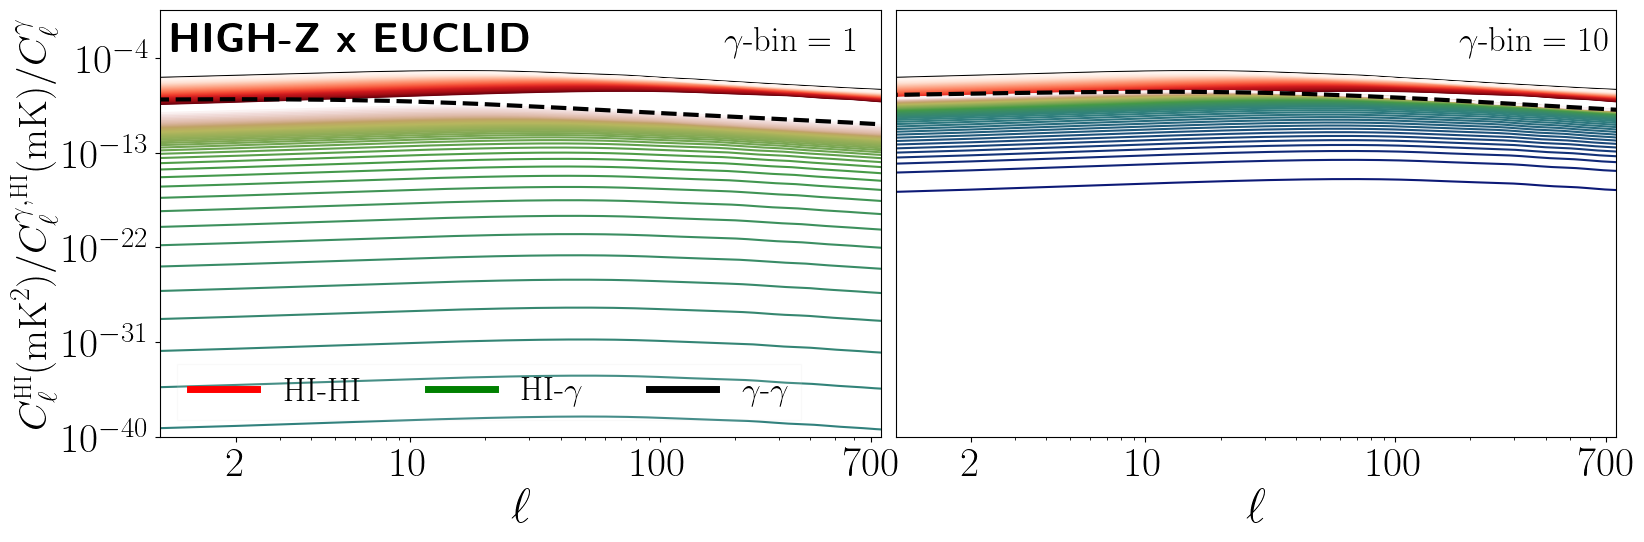

In [157]:
fig, axes  = plt.subplots(nrows=1, ncols=2)
plt.subplots_adjust(top=1.,right=2.4, wspace=0.02, )
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.gist_earth)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
ax = axes[0]
ishear = bshear_names[0]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK}^2)$' + r'$/$'+ r'$C^{\tiny{\gamma},\LARGE{\textrm{HI}}}_{\ell}(\textrm{mK})$'+ r'$/$'+ r'$C^{\tiny{\gamma}}_{\ell}$', fontsize=29); 
ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-40, 4e0])
ax.tick_params(axis='both', which='major', labelsize=30)
#
ax = axes[1]
ishear = bshear_names[1]
#
ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':ax.loglog(Clcx_dict[ishear]['l'], Clcx_dict[ishear][iname], linestyle='solid', color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.loglog(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.loglog(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.loglog(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
ax.set_xlabel(r'$\ell$', fontsize=35)
#ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
cxticks = [2, 10, 100, 700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-40, 4e0])
ax.set_yticks([])
ax.tick_params(axis='both', which='major', labelsize=30)
############################################################

###########################################################
ax = axes[0]
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='green',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='solid')]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{HI-}\gamma$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\gamma\textrm{-}\gamma$'#\ [\textrm{mK}^0]$'#\ (\textrm{m}=2)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1, y=4.0e-4, s=r'$\textbf{HIGH-Z x EUCLID}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
axes[0].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[0].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
axes[1].text(x=300-120, y=4.0e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(bshear_names[1].split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 25})
###########################################################
if suffix==None: pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}.png".format( prefix, 'cl_hi_theory')
else:            pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}_{}__{}.png".format(prefix, 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname